<a href="https://colab.research.google.com/github/sakshibhutekar/Ml-Models/blob/main/Regression/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np


In [8]:
df = sns.load_dataset('iris')
df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [3]:
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [4]:
print(df.isnull().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [10]:
df= df[df['species']!= 'virginica']
#making dateset binary

In [11]:
df['species']=df['species'].map({'setosa':0,'versicolor':1,})


In [13]:
#train test split
X = df.iloc[:, :-1]
y = df.iloc[:, -1]


from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
# model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [15]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

parametres = {
    'penalty':['l1','l2'],
    'C':[1,2,3,4,5,6,7,8,9,30],
    'max_iter':[100,200,300]
}

grid_search = GridSearchCV(estimator=model,param_grid=parametres,cv=5,scoring='accuracy')


In [17]:
grid_search.fit(  X_train,y_train)
grid_search.best_params_
grid_search.best_score_
classifier = grid_search.best_estimator_

print(classifier.score(X_train,y_train))
print(classifier.score(X_test,y_test))

1.0
1.0


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
150 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
150 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_sol

In [18]:
#prdiction and evaluation
y_pred = classifier.predict(X_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


1.0
[[12  0]
 [ 0  8]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



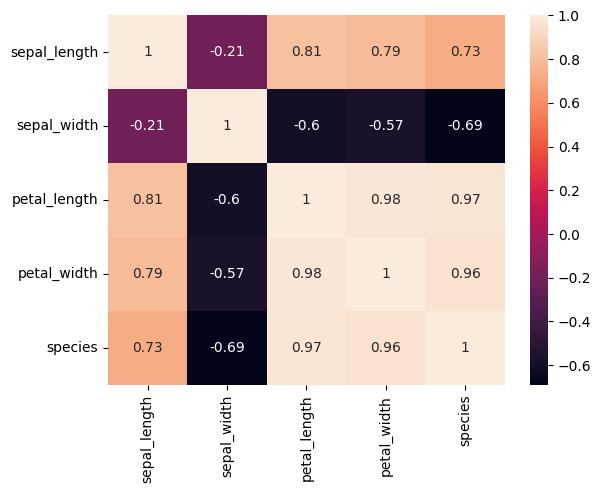

In [19]:
# heatmap
import matplotlib.pyplot as plt
sns.heatmap(df.corr(),annot=True)
plt.show()